In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import warnings
warnings.filterwarnings('ignore')

In [2]:
pip install matplotlib

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/9.3 MB ? eta -:--:--
   ---------- ----------------------------- 2.4/9.3 MB 11.2 MB/s eta 0:00:01
   --------------------- ------------------ 5.0/9.3 MB 11.6 MB/s eta 0:00:01
   ------------------------------ --------- 7.1/9.3 MB 11.5 MB/s eta 0:00:01
   ------------------------------------- -- 8.7/9.3 MB 10.5 MB/s eta 0:00:01
   ---------------------------------------- 9.3/9.3 MB 9.5 MB/s eta 0:00:00
   ---------------------------------------- 0.0/2.3 MB ? eta -:--:--
   ------------------------------- -------- 1.8/2.3 MB 9.1 MB/s eta 0:00:01
   ---------------------------------------- 2.3/2.3 MB 7.4 MB/s eta 0:00:00
   ---------------------------------------- 0.0/7.2 MB ? eta -:--:--
   ----------- ---------------------------- 2.1/7.2 MB 10.7 MB/s eta 0:00:01
   ------------------------ --------------- 4.5/7.2 MB 11.7 MB/s eta 0:00:01
   ----------------------

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: C:\Program Files\Python312\python.exe -m pip install --upgrade pip


In [3]:
pip install seaborn

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: C:\Program Files\Python312\python.exe -m pip install --upgrade pip


In [4]:
pip install sklearn

Defaulting to user installation because normal site-packages is not writeable
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'error'
Note: you may need to restart the kernel to use updated packages.


  error: subprocess-exited-with-error
  
  Getting requirements to build wheel did not run successfully.
  exit code: 1
  
  [15 lines of output]
  The 'sklearn' PyPI package is deprecated, use 'scikit-learn'
  rather than 'sklearn' for pip commands.
  
  Here is how to fix this error in the main use cases:
  - use 'pip install scikit-learn' rather than 'pip install sklearn'
  - replace 'sklearn' by 'scikit-learn' in your pip requirements files
    (requirements.txt, setup.py, setup.cfg, Pipfile, etc ...)
  - if the 'sklearn' package is used by one of your dependencies,
    it would be great if you take some time to track which package uses
    'sklearn' instead of 'scikit-learn' and report it to their issue tracker
  - as a last resort, set the environment variable
    SKLEARN_ALLOW_DEPRECATED_SKLEARN_PACKAGE_INSTALL=True to avoid this error
  
  More information is available at
  https://github.com/scikit-learn/sklearn-pypi-package
  [end of output]
  
  note: This error originates f

In [6]:
wdi = pd.read_csv("C:/Users/baki5002/Downloads/New folder (3)/Fyi/WDICSV.csv", low_memory=False)

fao = pd.read_csv("C:/Users/baki5002/Downloads/New folder (3)/Fyi/FAOSTAT_data_en_7-21-2026.csv")

country_series = pd.read_csv("C:/Users/baki5002/Downloads/New folder (3)\Fyi/WDICountry.csv")

series_time = pd.read_csv("C:/Users/baki5002/Downloads/New folder (3)\Fyi/WDISeries.csv")

footnote = pd.read_csv("C:/Users/baki5002/Downloads/New folder (3)\Fyi/WDIfootnote.csv")

<>:5: SyntaxWarning: invalid escape sequence '\F'
<>:7: SyntaxWarning: invalid escape sequence '\F'
<>:9: SyntaxWarning: invalid escape sequence '\F'
<>:5: SyntaxWarning: invalid escape sequence '\F'
<>:7: SyntaxWarning: invalid escape sequence '\F'
<>:9: SyntaxWarning: invalid escape sequence '\F'
C:\Users\baki5002\AppData\Local\Temp\7\ipykernel_21232\2783965330.py:5: SyntaxWarning: invalid escape sequence '\F'
  country_series = pd.read_csv("C:/Users/baki5002/Downloads/New folder (3)\Fyi/WDICountry.csv")
C:\Users\baki5002\AppData\Local\Temp\7\ipykernel_21232\2783965330.py:7: SyntaxWarning: invalid escape sequence '\F'
  series_time = pd.read_csv("C:/Users/baki5002/Downloads/New folder (3)\Fyi/WDISeries.csv")
C:\Users\baki5002\AppData\Local\Temp\7\ipykernel_21232\2783965330.py:9: SyntaxWarning: invalid escape sequence '\F'
  footnote = pd.read_csv("C:/Users/baki5002/Downloads/New folder (3)\Fyi/WDIfootnote.csv")


In [7]:
print(wdi.shape)
print(fao.shape)

wdi.head()

(396970, 70)
(14075, 15)


,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
0,Africa Eastern and Southern,AFE,Access to clean fuels and technologies for coo...,EG.CFT.ACCS.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,18.685118,19.205632,19.742772,20.332679,20.862800,21.419621,21.996456,22.541440,NaN,NaN
1,Africa Eastern and Southern,AFE,Access to clean fuels and technologies for coo...,EG.CFT.ACCS.RU.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,7.606712,7.926604,8.309896,8.704591,9.106640,9.480804,9.903209,10.288154,NaN,NaN
2,Africa Eastern and Southern,AFE,Access to clean fuels and technologies for coo...,EG.CFT.ACCS.UR.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,39.052626,39.321068,39.649534,39.968299,40.354628,40.723805,41.026351,41.289974,NaN,NaN
3,Africa Eastern and Southern,AFE,Access to electricity (% of population),EG.ELC.ACCS.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,38.859598,40.223744,43.035073,44.390861,46.282371,48.127211,48.742043,50.667516,52.598171,NaN
4,Africa Eastern and Southern,AFE,"Access to electricity, rural (% of rural popul...",EG.ELC.ACCS.RU.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,24.584906,25.375037,26.941984,28.983183,30.909991,32.709837,33.998179,35.240236,36.080572,NaN


In [8]:
wdi.info()

wdi.describe(include='all')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 396970 entries, 0 to 396969
Data columns (total 70 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   Country Name    396970 non-null  object 
 1   Country Code    396970 non-null  object 
 2   Indicator Name  396970 non-null  object 
 3   Indicator Code  396970 non-null  object 
 4   1960            37226 non-null   float64
 5   1961            42560 non-null   float64
 6   1962            43847 non-null   float64
 7   1963            44777 non-null   float64
 8   1964            45283 non-null   float64
 9   1965            47096 non-null   float64
 10  1966            47354 non-null   float64
 11  1967            47991 non-null   float64
 12  1968            48608 non-null   float64
 13  1969            49391 non-null   float64
 14  1970            72137 non-null   float64
 15  1971            76468 non-null   float64
 16  1972            78158 non-null   float64
 17  1973      

,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
count,396970,396970,396970,396970,3.722600e+04,4.256000e+04,4.384700e+04,4.477700e+04,4.528300e+04,4.709600e+04,...,2.254450e+05,2.233370e+05,2.224570e+05,2.195450e+05,2.170060e+05,2.114730e+05,1.979960e+05,1.841720e+05,1.501580e+05,8.167100e+04
unique,265,265,1498,1498,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,Africa Eastern and Southern,AFE,Access to clean fuels and technologies for coo...,EG.CFT.ACCS.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,1498,1498,265,265,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,NaN,1.867811e+12,1.739241e+12,1.783731e+12,1.852442e+12,2.005721e+12,2.237983e+12,...,5.849859e+12,6.241333e+12,6.506322e+12,3.133253e+13,3.829790e+14,2.049124e+15,1.558836e+16,5.942646e+16,1.622408e+17,5.162488e+13
std,NaN,NaN,NaN,NaN,9.560066e+13,9.646630e+13,1.013853e+14,1.072434e+14,1.161280e+14,1.328337e+14,...,4.003583e+14,4.220882e+14,4.091528e+14,1.151336e+16,1.748442e+17,9.378512e+17,6.930490e+18,2.549565e+19,6.285899e+19,2.768052e+15
min,NaN,NaN,NaN,NaN,-6.983892e+14,-1.048260e+15,-1.190074e+15,-1.321699e+15,-1.403476e+15,-1.815444e+15,...,-3.970130e+14,-4.306058e+14,-4.421837e+14,-3.551874e+15,-6.131892e+15,-4.608969e+14,-5.290986e+14,-3.846495e+15,-4.178515e+17,-2.352286e+16
25%,NaN,NaN,NaN,NaN,4.509557e+00,4.571029e+00,4.631218e+00,4.725734e+00,4.806098e+00,4.555055e+00,...,5.119712e+00,5.555556e+00,5.067547e+00,5.265751e+00,5.202915e+00,5.744985e+00,5.729237e+00,5.888326e+00,6.000000e+00,6.624572e+00
50%,NaN,NaN,NaN,NaN,3.707037e+01,3.795417e+01,3.681300e+01,3.644828e+01,3.736586e+01,3.738461e+01,...,3.890500e+01,4.163844e+01,3.899901e+01,3.998688e+01,4.074169e+01,4.141402e+01,4.297104e+01,4.563122e+01,4.712648e+01,4.307289e+01
75%,NaN,NaN,NaN,NaN,9.408000e+04,8.146325e+04,7.330000e+04,7.230000e+04,8.439050e+04,1.190202e+05,...,6.468000e+03,9.013000e+03,8.839869e+03,1.115300e+04,1.131673e+04,1.290700e+04,1.532835e+04,3.021365e+04,2.243530e+04,2.705319e+06


In [9]:
nigeria = wdi[
    wdi['Country Name']
    .str.contains(
        'Nigeria',
        na=False
    )
]

nigeria.shape

(1498, 70)

In [10]:
key_indicators = [

    'Population, total',

    'GDP per capita',

    'Urban population',

    'Inflation',

    'Household final consumption expenditure',

    'Employment',

    'Internet users',

    'Food imports'

]

In [12]:
indicator_df = nigeria[
    nigeria['Indicator Name']
    .isin(key_indicators)
]


In [13]:
years = [str(x)
         for x in range(
             2000,
             2025
         )]

long_df = indicator_df.melt(

    id_vars=[
        'Country Name',
        'Indicator Name'
    ],

    value_vars=years,

    var_name='Year',

    value_name='Value'
)

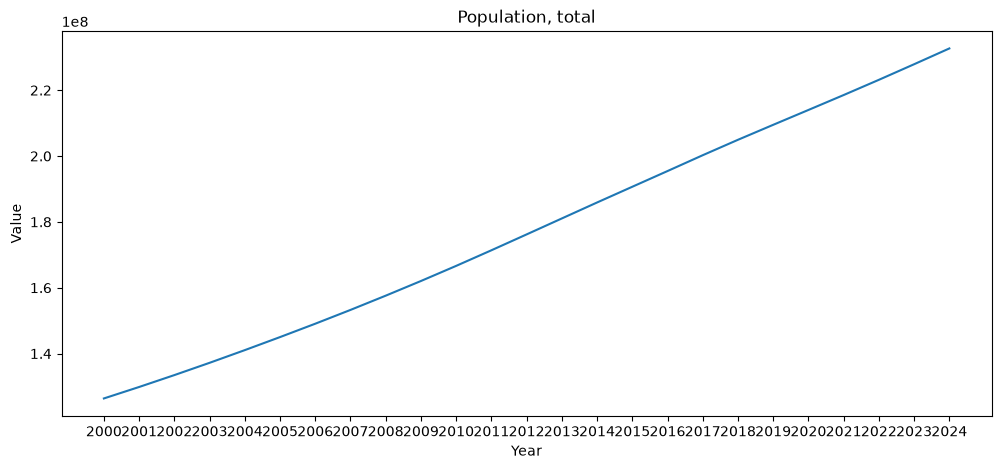

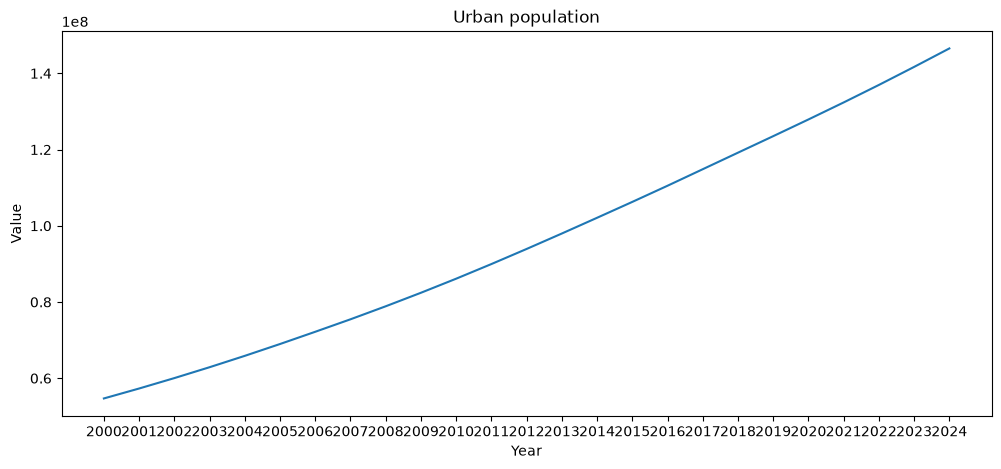

In [14]:
for indicator in long_df[
    'Indicator Name'
].unique():

    temp = long_df[
        long_df['Indicator Name']
        == indicator
    ]

    plt.figure(figsize=(12,5))

    sns.lineplot(
        x='Year',
        y='Value',
        data=temp
    )

    plt.title(indicator)

    plt.show()

In [15]:
fao.columns


Index(['Domain Code', 'Domain', 'Area Code (M49)', 'Area', 'Element Code',
       'Element', 'Item Code (CPC)', 'Item', 'Year Code', 'Year', 'Unit',
       'Value', 'Flag', 'Flag Description', 'Note'],
      dtype='object')

In [16]:
nigeria_cocoa = fao[
    fao.astype(str)
       .apply(
           lambda x:
           x.str.contains(
               'Nigeria',
               case=False
           )
       ).any(axis=1)
]

Text(0.5, 1.0, 'Nigeria Cocoa Trend')

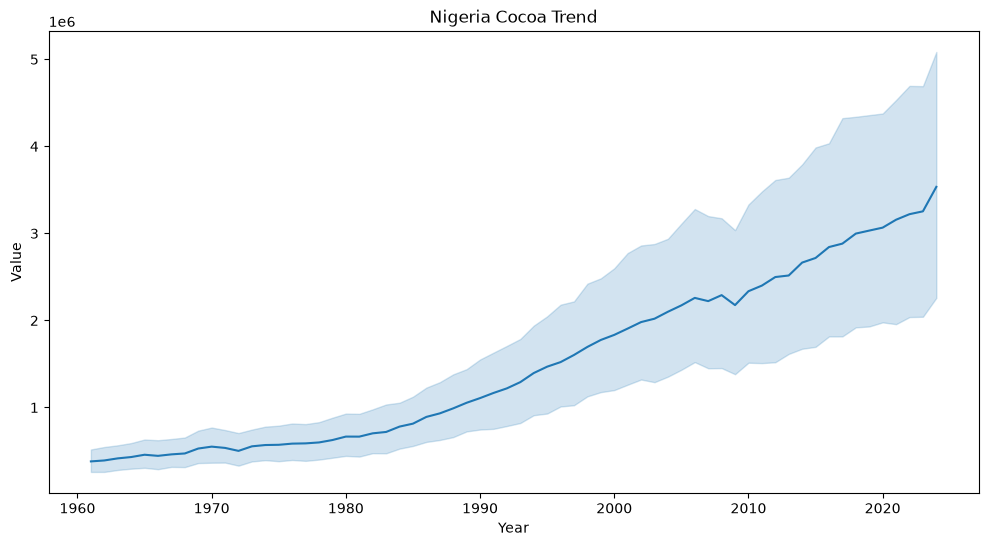

In [17]:
plt.figure(figsize=(12,6))

sns.lineplot(
    data=nigeria_cocoa,
    x='Year',
    y='Value'
)

plt.title(
    'Nigeria Cocoa Trend'
)


In [18]:
population = long_df[
    long_df[
        'Indicator Name'
    ].str.contains(
        'Population',
        na=False
    )
]

In [19]:
urban = long_df[
    long_df[
        'Indicator Name'
    ].str.contains(
        'Urban',
        na=False
    )
]

<Axes: xlabel='Indicator Name', ylabel='Indicator Name'>

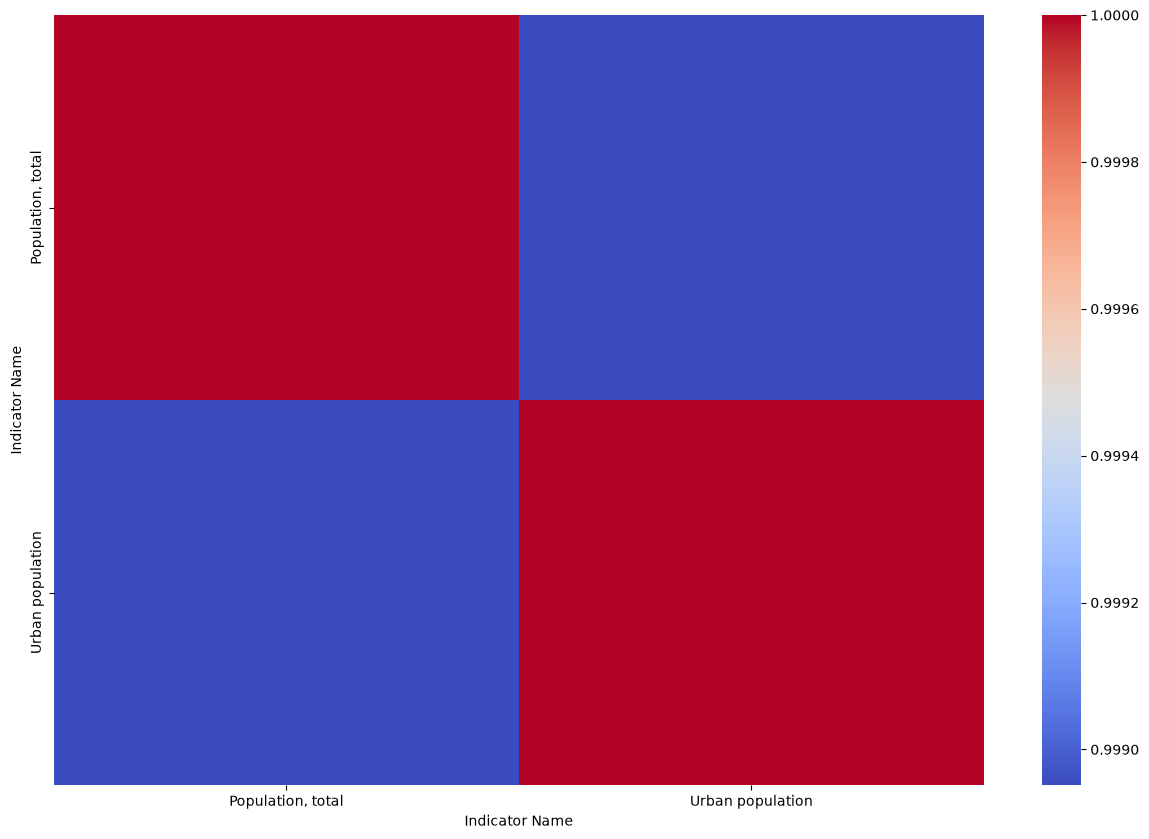

In [20]:
pivot_df = long_df.pivot_table(

    index='Year',

    columns='Indicator Name',

    values='Value'

)

corr = pivot_df.corr()

plt.figure(figsize=(15,10))

sns.heatmap(
    corr,
    cmap='coolwarm'
)

In [22]:
# ====================================================
# FEATURE ENGINEERING (ROBUST VERSION)
# ====================================================

print("Available Columns:")
print(pivot_df.columns.tolist())

# Find columns automatically

population_candidates = [
    c for c in pivot_df.columns
    if 'Population, total' in str(c)
]

gdp_candidates = [
    c for c in pivot_df.columns
    if 'GDP per capita' in str(c)
]

urban_candidates = [
    c for c in pivot_df.columns
    if 'Urban population' in str(c)
]

print("\nPopulation Columns:", population_candidates)
print("GDP Columns:", gdp_candidates)
print("Urban Columns:", urban_candidates)

# Select first matching column

population_col = population_candidates[0] if len(population_candidates) > 0 else None
gdp_col = gdp_candidates[0] if len(gdp_candidates) > 0 else None
urban_col = urban_candidates[0] if len(urban_candidates) > 0 else None

# Create growth features safely

if population_col:
    pivot_df['Population_Growth'] = (
        pivot_df[population_col]
        .astype(float)
        .pct_change()
    )

if gdp_col:
    pivot_df['GDP_Growth'] = (
        pivot_df[gdp_col]
        .astype(float)
        .pct_change()
    )

if urban_col:
    pivot_df['Urban_Growth'] = (
        pivot_df[urban_col]
        .astype(float)
        .pct_change()
    )

# Fill missing values

pivot_df = pivot_df.fillna(method='ffill')
pivot_df = pivot_df.fillna(method='bfill')

# Create Opportunity Score only from available features

growth_features = []

if 'Population_Growth' in pivot_df.columns:
    growth_features.append('Population_Growth')

if 'GDP_Growth' in pivot_df.columns:
    growth_features.append('GDP_Growth')

if 'Urban_Growth' in pivot_df.columns:
    growth_features.append('Urban_Growth')

pivot_df['OpportunityScore'] = (
    pivot_df[growth_features]
    .mean(axis=1)
)

print("\nFeature Engineering Complete")
print(pivot_df[['OpportunityScore'] + growth_features].head())
print("\nShape:", pivot_df.shape)

Available Columns:
['Population, total', 'Urban population', 'Population_Growth']

Population Columns: ['Population, total']
GDP Columns: []
Urban Columns: ['Urban population']

Feature Engineering Complete
Indicator Name  OpportunityScore  Population_Growth  Urban_Growth
Year                                                             
2000                    0.037600           0.027536      0.047664
2001                    0.037600           0.027536      0.047664
2002                    0.037729           0.027794      0.047664
2003                    0.037754           0.027951      0.047557
2004                    0.037763           0.028093      0.047433

Shape: (25, 5)


C:\Users\baki5002\AppData\Local\Temp\7\ipykernel_21232\1824905448.py:60: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  pivot_df = pivot_df.fillna(method='ffill')
C:\Users\baki5002\AppData\Local\Temp\7\ipykernel_21232\1824905448.py:61: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  pivot_df = pivot_df.fillna(method='bfill')


In [24]:
# ====================================================
# MODEL DATASET
# ====================================================

required_features = []

if 'Population_Growth' in pivot_df.columns:
    required_features.append('Population_Growth')

if 'GDP_Growth' in pivot_df.columns:
    required_features.append('GDP_Growth')

if 'Urban_Growth' in pivot_df.columns:
    required_features.append('Urban_Growth')

model_df = pivot_df.copy()

model_df = model_df.dropna(
    subset=['OpportunityScore']
)

print(model_df.shape)

model_df.head()

(25, 5)


Indicator Name,"Population, total",Urban population,Population_Growth,Urban_Growth,OpportunityScore
Year,,,,,
2000,126382494.0,54696454.0,0.027536,0.047664,0.037600
2001,129862595.0,57303483.0,0.027536,0.047664,0.037600
2002,133471989.0,60034770.0,0.027794,0.047664,0.037729
2003,137202644.0,62889861.0,0.027951,0.047557,0.037754
2004,141057045.0,65872907.0,0.028093,0.047433,0.037763


In [25]:
# ====================================================
# MODEL DATASET
# ====================================================

required_features = []

if 'Population_Growth' in pivot_df.columns:
    required_features.append('Population_Growth')

if 'GDP_Growth' in pivot_df.columns:
    required_features.append('GDP_Growth')

if 'Urban_Growth' in pivot_df.columns:
    required_features.append('Urban_Growth')

model_df = pivot_df.copy()

model_df = model_df.dropna(
    subset=['OpportunityScore']
)

print(model_df.shape)

model_df.head()

(25, 5)


Indicator Name,"Population, total",Urban population,Population_Growth,Urban_Growth,OpportunityScore
Year,,,,,
2000,126382494.0,54696454.0,0.027536,0.047664,0.037600
2001,129862595.0,57303483.0,0.027536,0.047664,0.037600
2002,133471989.0,60034770.0,0.027794,0.047664,0.037729
2003,137202644.0,62889861.0,0.027951,0.047557,0.037754
2004,141057045.0,65872907.0,0.028093,0.047433,0.037763


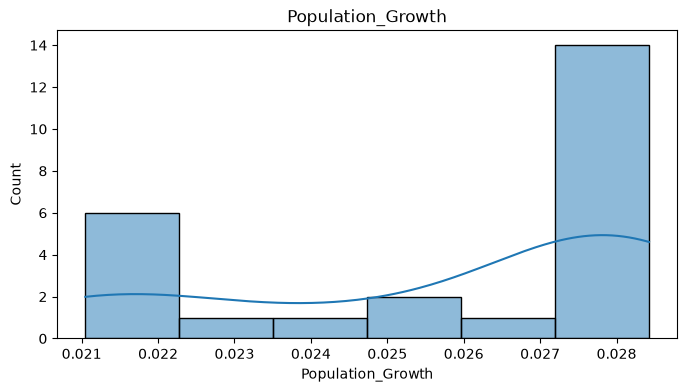

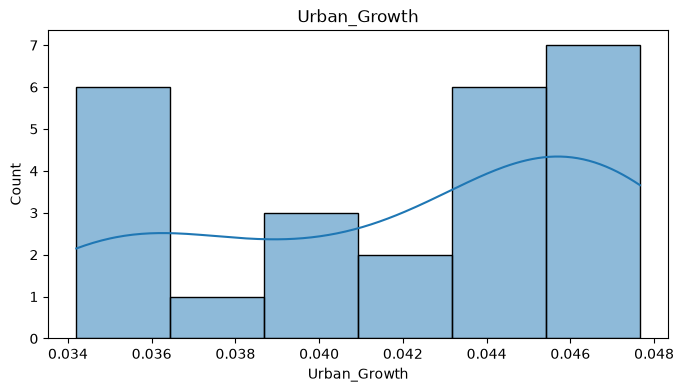

In [26]:
for col in required_features:

    plt.figure(figsize=(8,4))

    sns.histplot(
        model_df[col],
        kde=True
    )

    plt.title(col)

    plt.show()

In [29]:
X = model_df[
    required_features
]

y = model_df[
    'OpportunityScore'
]

print("Features:")
print(X.columns)

print("\nTarget:")
print(y.name)

X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.20,

    random_state=42
)

print(X_train.shape)
print(X_test.shape)

Features:
Index(['Population_Growth', 'Urban_Growth'], dtype='object', name='Indicator Name')

Target:
OpportunityScore


NameError: name 'train_test_split' is not defined

In [30]:
pip install train_test_split

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


ERROR: Could not find a version that satisfies the requirement train_test_split (from versions: none)

[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: C:\Program Files\Python312\python.exe -m pip install --upgrade pip
ERROR: No matching distribution found for train_test_split
